# Tree-Based Ensemble Learning: Comparsion Study

## Models Compared
- Decision Tree 
- Bagging
- Random Forest
- AdaBoost
- Gradient Boosting

**Dataset:** IBM HR Analytics Employee Attrition 



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier


## Load Dataset

In [2]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
display(df.head())
print(df.shape)
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

## Minimal Preprocessing

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])





In [5]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

## 1. Decision Tree

Accuracy: 0.7653061224489796
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       247
           1       0.30      0.34      0.32        47

    accuracy                           0.77       294
   macro avg       0.58      0.59      0.59       294
weighted avg       0.78      0.77      0.77       294



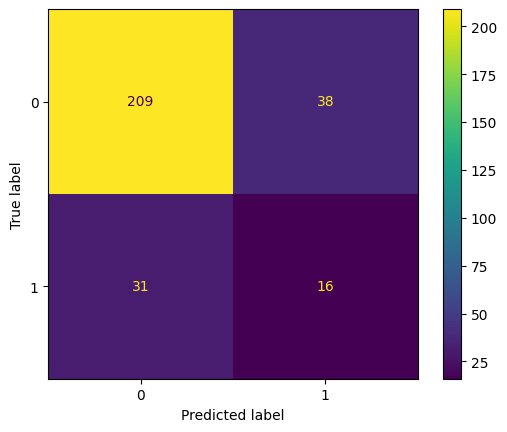

In [7]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_dt))
print(classification_report(y_test,pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test,pred_dt)
plt.show()

## 2. Bagging

In [8]:
bag=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,random_state=42)
bag.fit(X_train,y_train)
pred_bag=bag.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_bag))

Accuracy: 0.8435374149659864


## 3. Random Forest + GridSearchCV

In [ ]:
params={"n_estimators":[100,200],"max_depth":[None,5,10],"max_features":["sqrt","log2"]}

grid=GridSearchCV(RandomForestClassifier(random_state=42),params,cv=5,n_jobs=-1,scoring="accuracy")

grid.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [10]:
rf=grid.best_estimator_
print(grid.best_params_)
pred_rf=rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_rf))

{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Accuracy: 0.8299319727891157


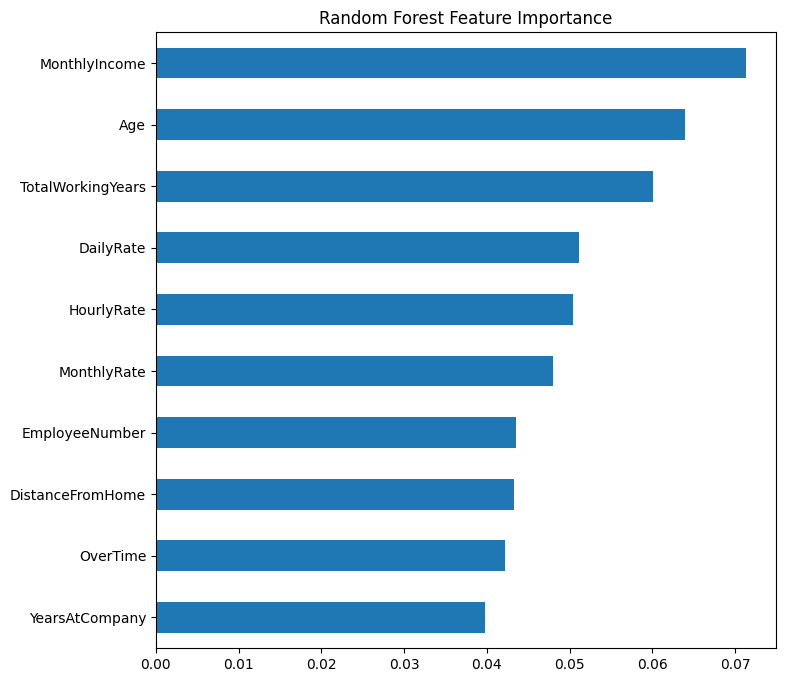

In [11]:
fi=pd.Series(rf.feature_importances_,index=X.columns).sort_values()

plt.figure(figsize=(8,8))
fi.tail(10).plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

## 4. AdaBoost

In [12]:
ada=AdaBoostClassifier(n_estimators=200,learning_rate=0.5,random_state=42)

ada.fit(X_train,y_train)
pred_ada=ada.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_ada))

Accuracy: 0.8571428571428571


## 5. Gradient Boosting

In [13]:
gb=GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,random_state=42)

In [14]:
gb.fit(X_train,y_train)
pred_gb=gb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_gb))


Accuracy: 0.8367346938775511


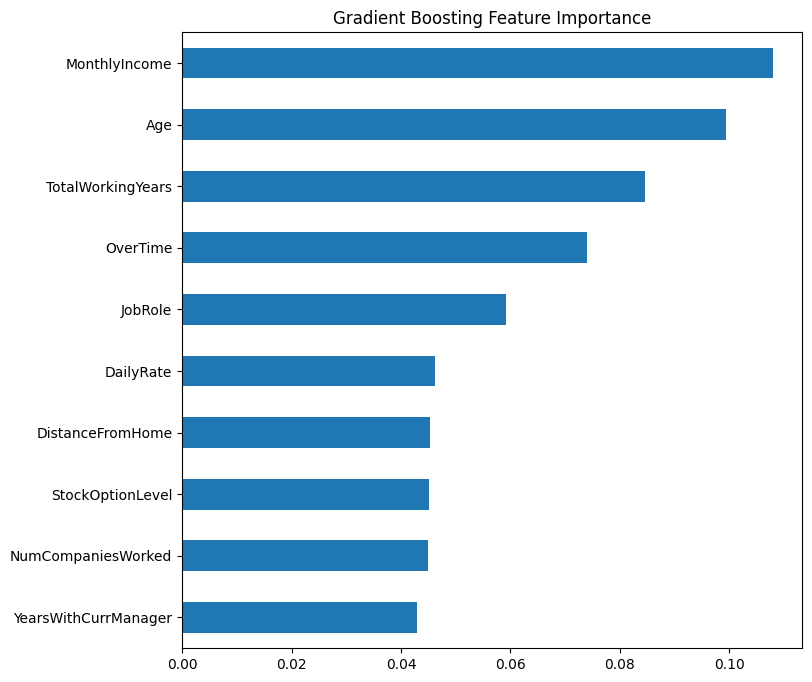

In [15]:
fi=pd.Series(gb.feature_importances_,index=X.columns).sort_values()
plt.figure(figsize=(8,8))
fi.tail(10).plot(kind="barh")
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [17]:
from xgboost import XGBClassifier

In [21]:


xgb = XGBClassifier(n_estimators=300,learning_rate=0.1,max_depth=4,subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric='logloss')

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_xgb))



XGBoost Accuracy: 0.8605442176870748

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.69      0.23      0.35        47

    accuracy                           0.86       294
   macro avg       0.78      0.61      0.64       294
weighted avg       0.84      0.86      0.83       294



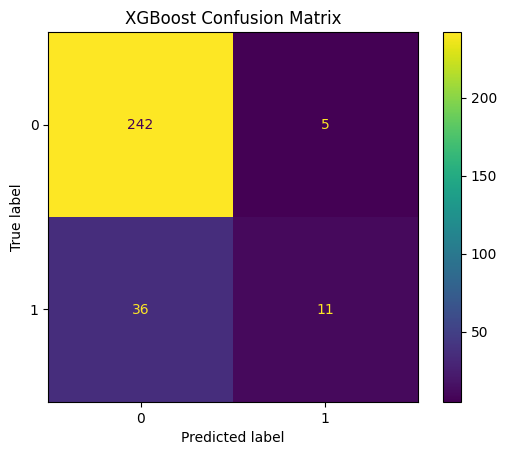

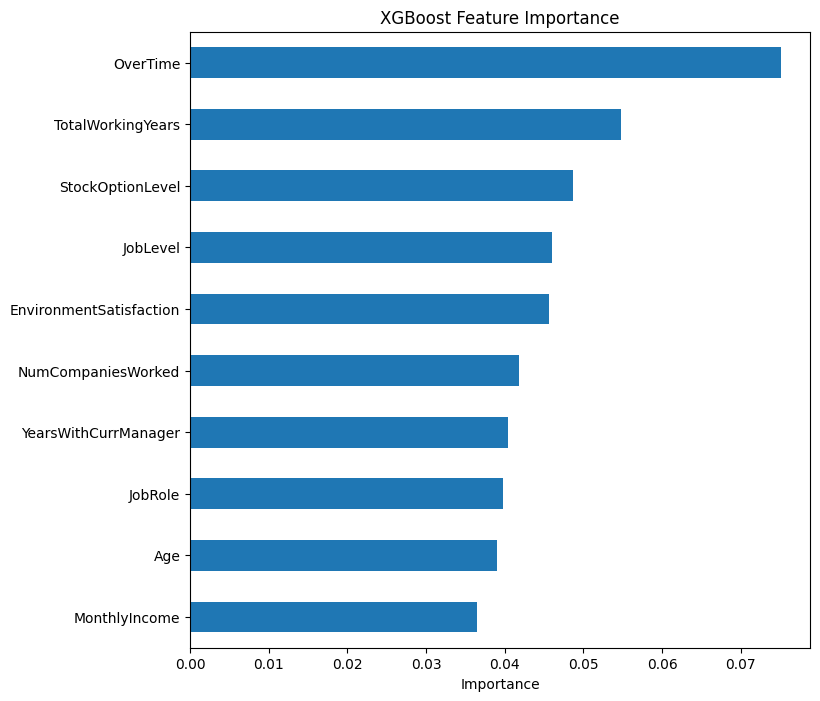

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb)
plt.title("XGBoost Confusion Matrix")
plt.show()


importance = pd.Series(xgb.feature_importances_,index=X.columns).sort_values()

plt.figure(figsize=(8,8))
importance.tail(10).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

## Model Comparison

In [23]:
results = pd.DataFrame({
    "Model": ["Decision Tree","Bagging","Random Forest","AdaBoost","Gradient Boosting","XGBoost"],
    "Accuracy": [accuracy_score(y_test, pred_dt),accuracy_score(y_test, pred_bag),accuracy_score(y_test, pred_rf),accuracy_score(y_test, pred_ada),accuracy_score(y_test, pred_gb),accuracy_score(y_test, pred_xgb)]
})

results = results.sort_values(by="Accuracy", ascending=False)

display(results)



,Model,Accuracy
5,XGBoost,0.860544
3,AdaBoost,0.857143
1,Bagging,0.843537
4,Gradient Boosting,0.836735
2,Random Forest,0.829932
0,Decision Tree,0.765306


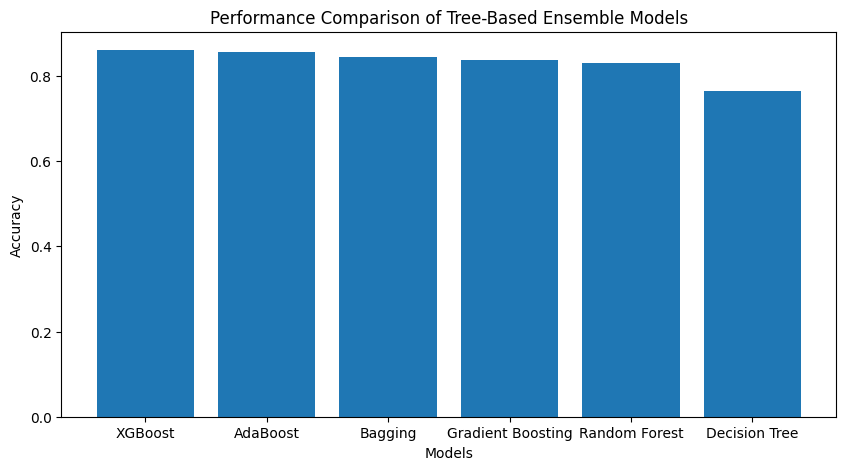

In [27]:
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Performance Comparison of Tree-Based Ensemble Models")

plt.show()
